In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

In [6]:
df = pd.read_csv("Titanic Dataset.csv")
df.head(5)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [11]:
df.isnull().sum()


pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [21]:
si = SimpleImputer(strategy = "mean")
df["age"] = si.fit_transform(df[["age"]])
df["body"] = si.fit_transform(df[["body"]])
df["fare"] = si.fit_transform(df[["fare"]])
cate_si = SimpleImputer(strategy = "most_frequent")
df[["home.dest"]] = cate_si.fit_transform(df[["home.dest"]])
df[["embarked"]] = cate_si.fit_transform(df[["embarked"]])
df[["cabin"]] = cate_si.fit_transform(df[["cabin"]])
df[["boat"]] = cate_si.fit_transform(df[["boat"]])


In [28]:
li = LabelEncoder()
df["sex"] = li.fit_transform(df["sex"])
df["embarked"] = li.fit_transform(df["embarked"])

In [29]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [37]:
x = df[features]
y = df[target]
x_train,x_test, y_train,y_test = train_test_split(x,
                                                  y,
                                                  test_size=0.2, 
                                                  random_state = 40
)


In [38]:
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
y_pred = model.predict(x_test)
print("accuracy =",accuracy_score(y_test,y_pred))

accuracy = 0.7480916030534351


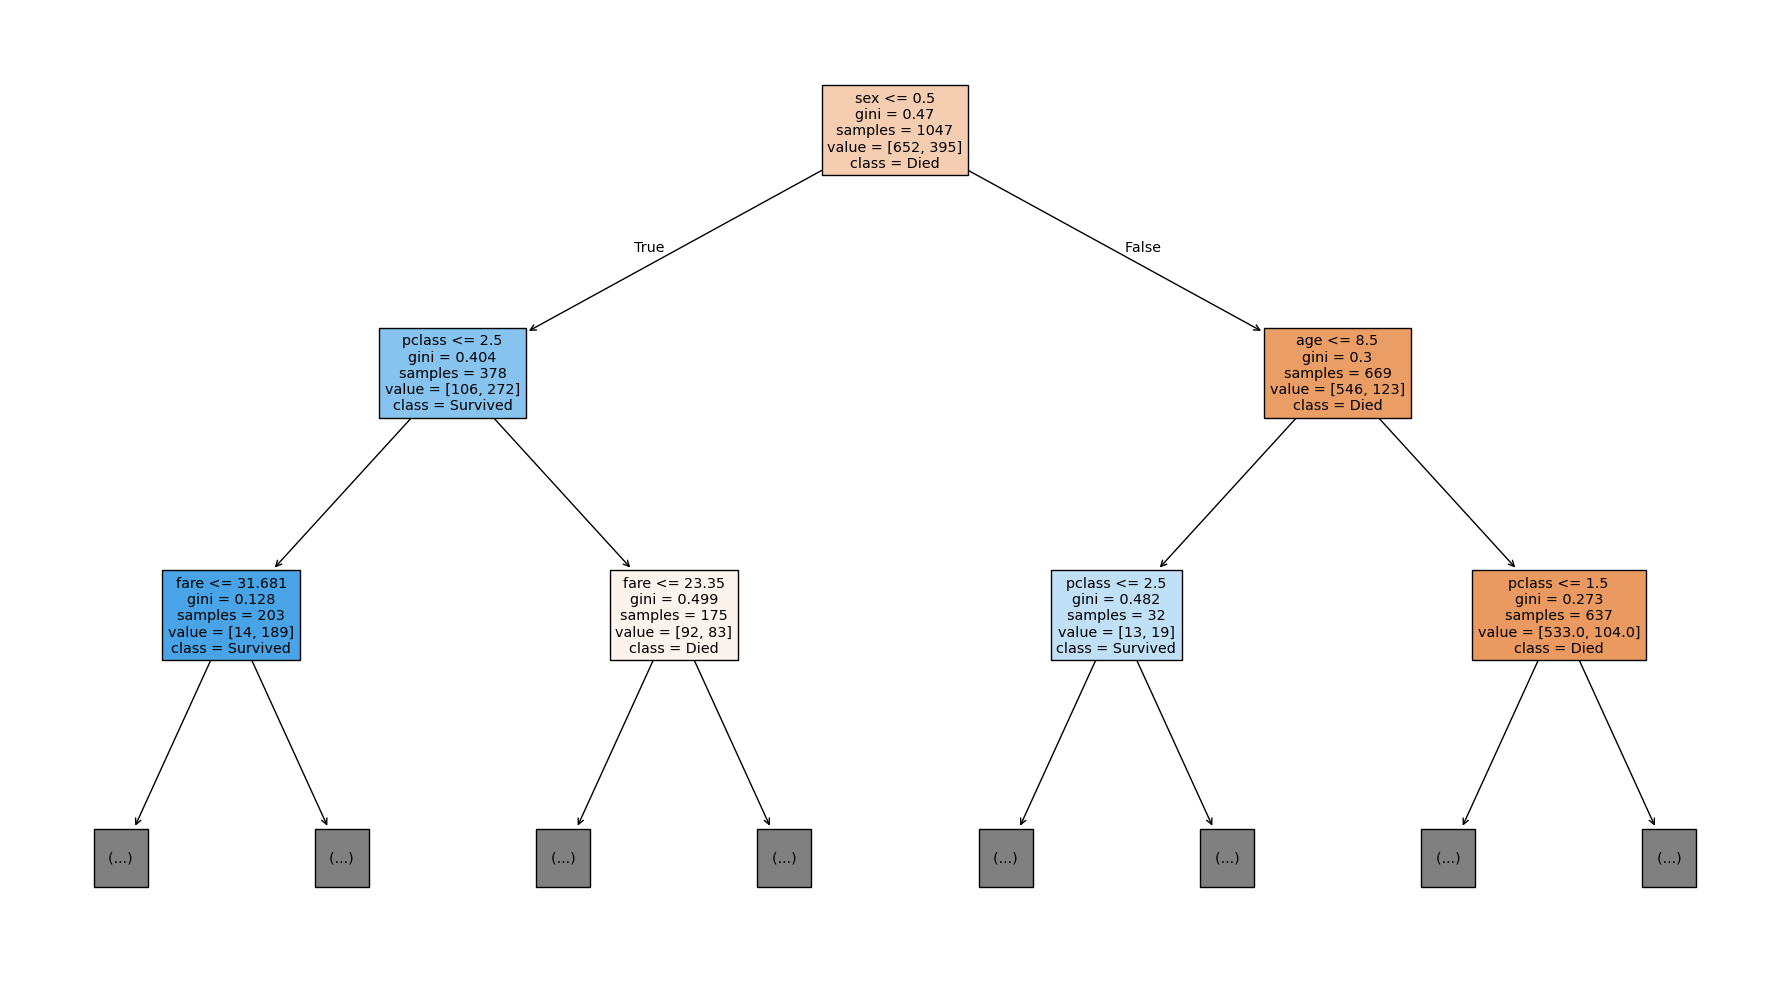

In [42]:
from sklearn.tree import plot_tree
plt.figure(figsize = (18,10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()

# Decision tree with pre pruning

for depth=2, accuracy=0.7557251908396947
for depth=3, accuracy=0.8015267175572519


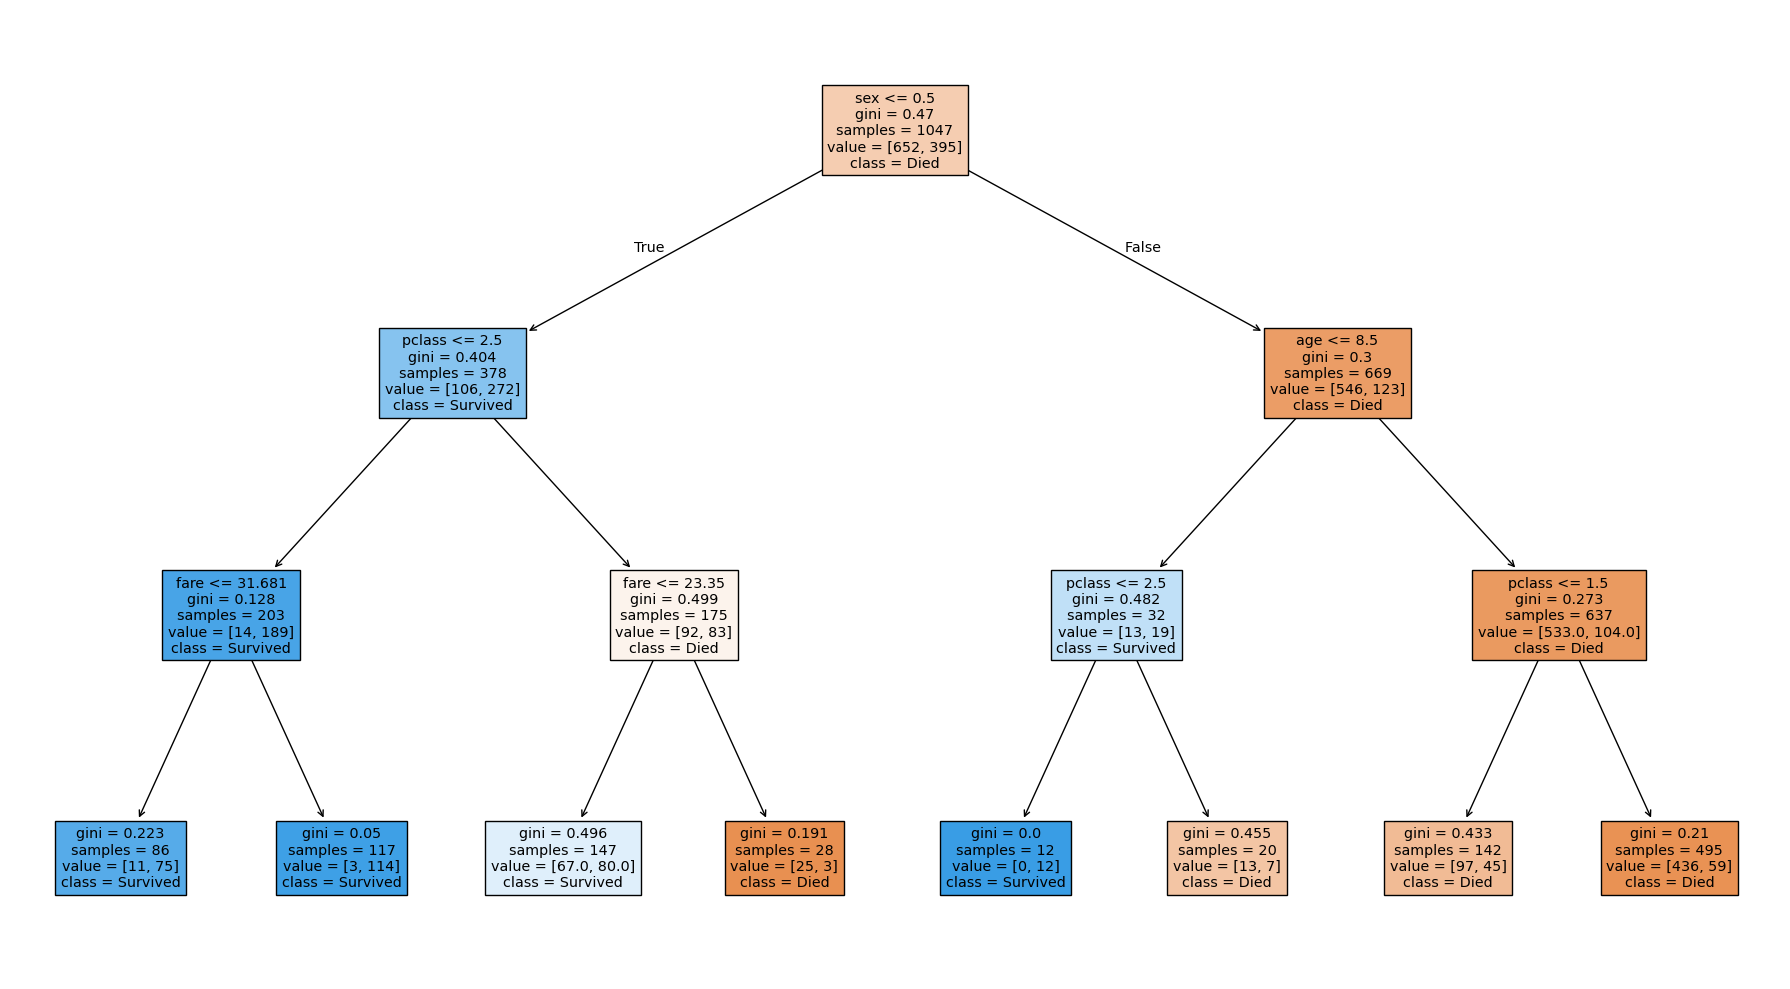

for depth=4, accuracy=0.7748091603053435
for depth=5, accuracy=0.7595419847328244
for depth=6, accuracy=0.7709923664122137
for depth=7, accuracy=0.7824427480916031
for depth=8, accuracy=0.7709923664122137


In [47]:
depth = [2,3,4,5,6,7,8]
for i in depth:
    model = DecisionTreeClassifier(max_depth= i)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for depth={i}, accuracy={acc}")
    if i==3:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=x.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

for sample=5, accuracy=0.8015267175572519
for sample=10, accuracy=0.8015267175572519


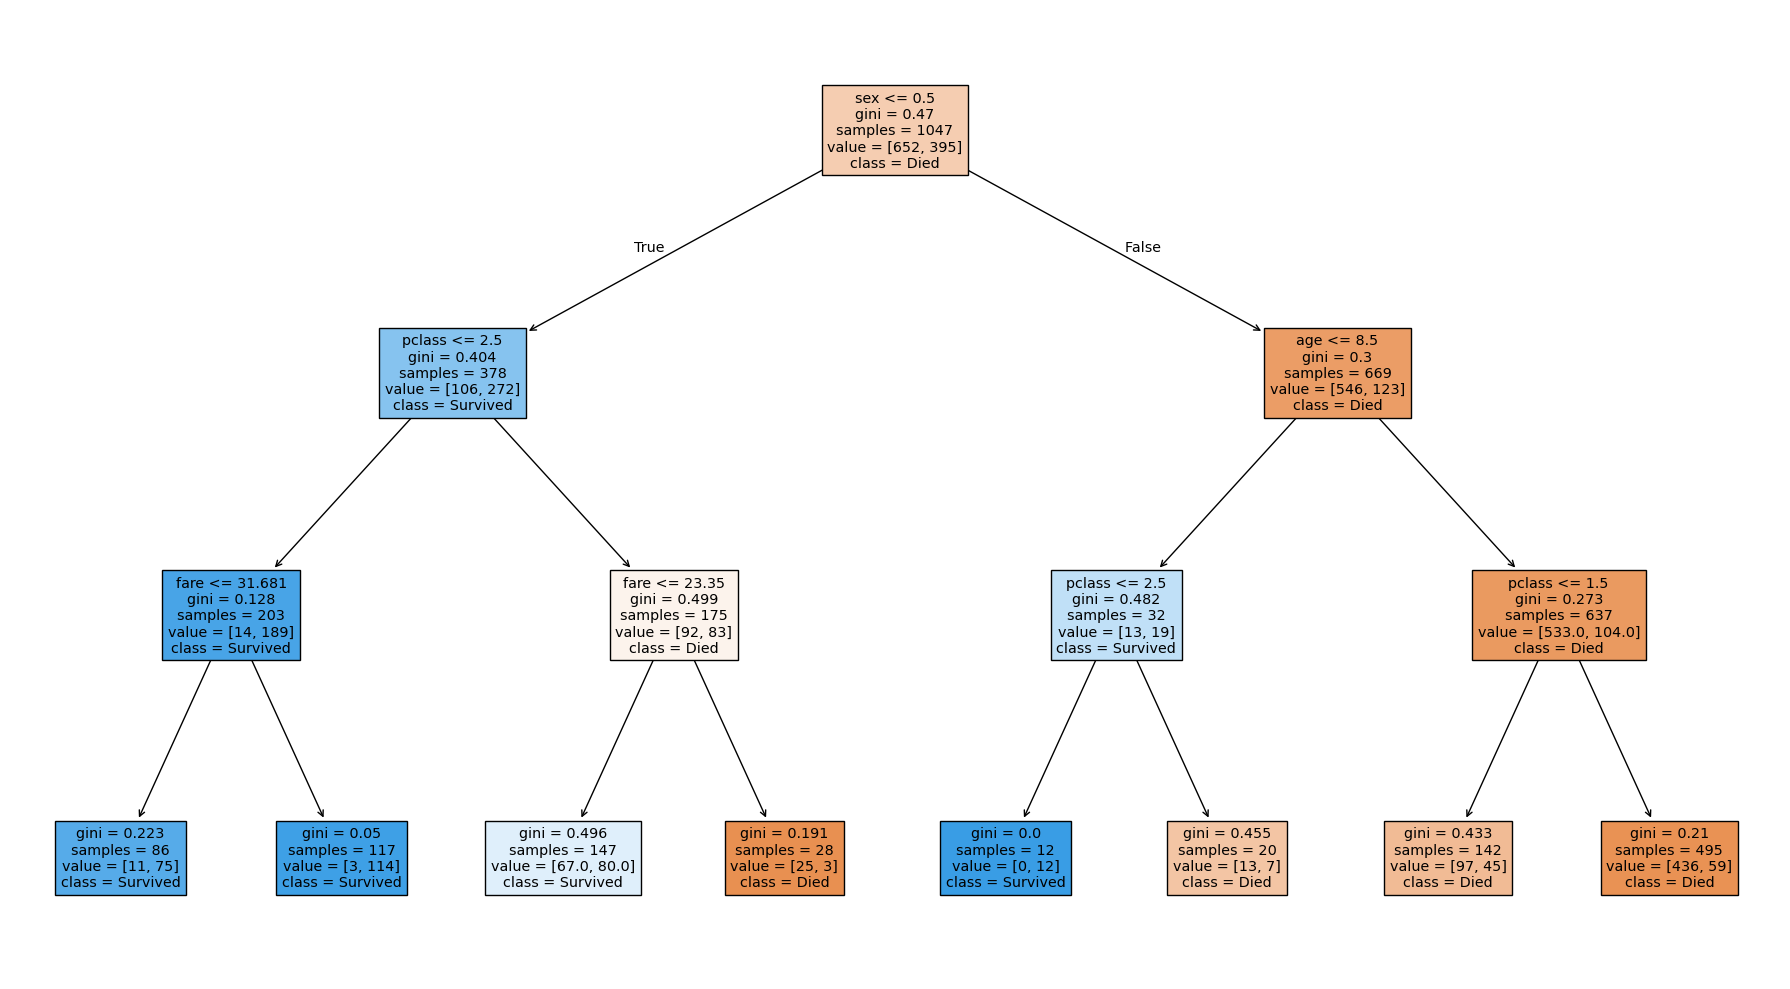

for sample=15, accuracy=0.8015267175572519
for sample=20, accuracy=0.8015267175572519
for sample=25, accuracy=0.8015267175572519


In [54]:
min_samples_split = [5,10,15,20,25]
for i in min_samples_split:
    model = DecisionTreeClassifier(max_depth= 3, min_samples_split = i)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for sample={i}, accuracy={acc}")
    if i==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=x.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

# Decision tree with post pruning

In [58]:
full_tree = DecisionTreeClassifier(random_state = 40)
full_tree.fit(x_train,y_train)
path = full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 7.95924865e-06 2.27407104e-05 5.77687402e-05
 7.95924865e-05 1.15770889e-04 1.27347978e-04 1.59184973e-04
 1.59184973e-04 1.79083095e-04 1.91021968e-04 2.45599673e-04
 2.65308288e-04 2.86532951e-04 3.18369946e-04 3.18369946e-04
 3.18369946e-04 3.27466230e-04 4.12853930e-04 4.44620097e-04
 4.58452722e-04 4.73252622e-04 4.85135156e-04 5.09391913e-04
 5.09391913e-04 5.09391913e-04 5.62611861e-04 5.83678234e-04
 6.03284067e-04 6.06775662e-04 6.16841770e-04 6.36739892e-04
 6.36739892e-04 6.41288034e-04 6.66758014e-04 6.89801549e-04
 6.96414604e-04 7.16332378e-04 7.64087870e-04 7.64087870e-04
 7.64087870e-04 7.64087870e-04 7.64087870e-04 7.64087870e-04
 7.80006367e-04 7.95924865e-04 7.95924865e-04 7.95924865e-04
 7.98819137e-04 8.06441157e-04 8.11843362e-04 8.30530294e-04
 8.35721108e-04 8.48986522e-04 8.52776641e-04 8.68281671e-04
 8.90290199e-04 8.91435848e-04 8.91435848e-04 8.91435848e-04
 9.19641568e-04 9.22677140e-04 9.62386865e-04 1.02674308e-03
 1.04000849e-03 1.073385

In [63]:
tress = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 40, ccp_alpha = alpha)
    model.fit(x_train,y_train)
    tress.append((model,alpha))

In [64]:
best_acc = 0
best_alpha = 0
for model, alpha in tress:
    cww = model.score(x_test,y_test)
    if cww > best_acc:
        best_acc = cww
        best_alpha = alpha
        

In [65]:
best_acc

0.8015267175572519

In [66]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


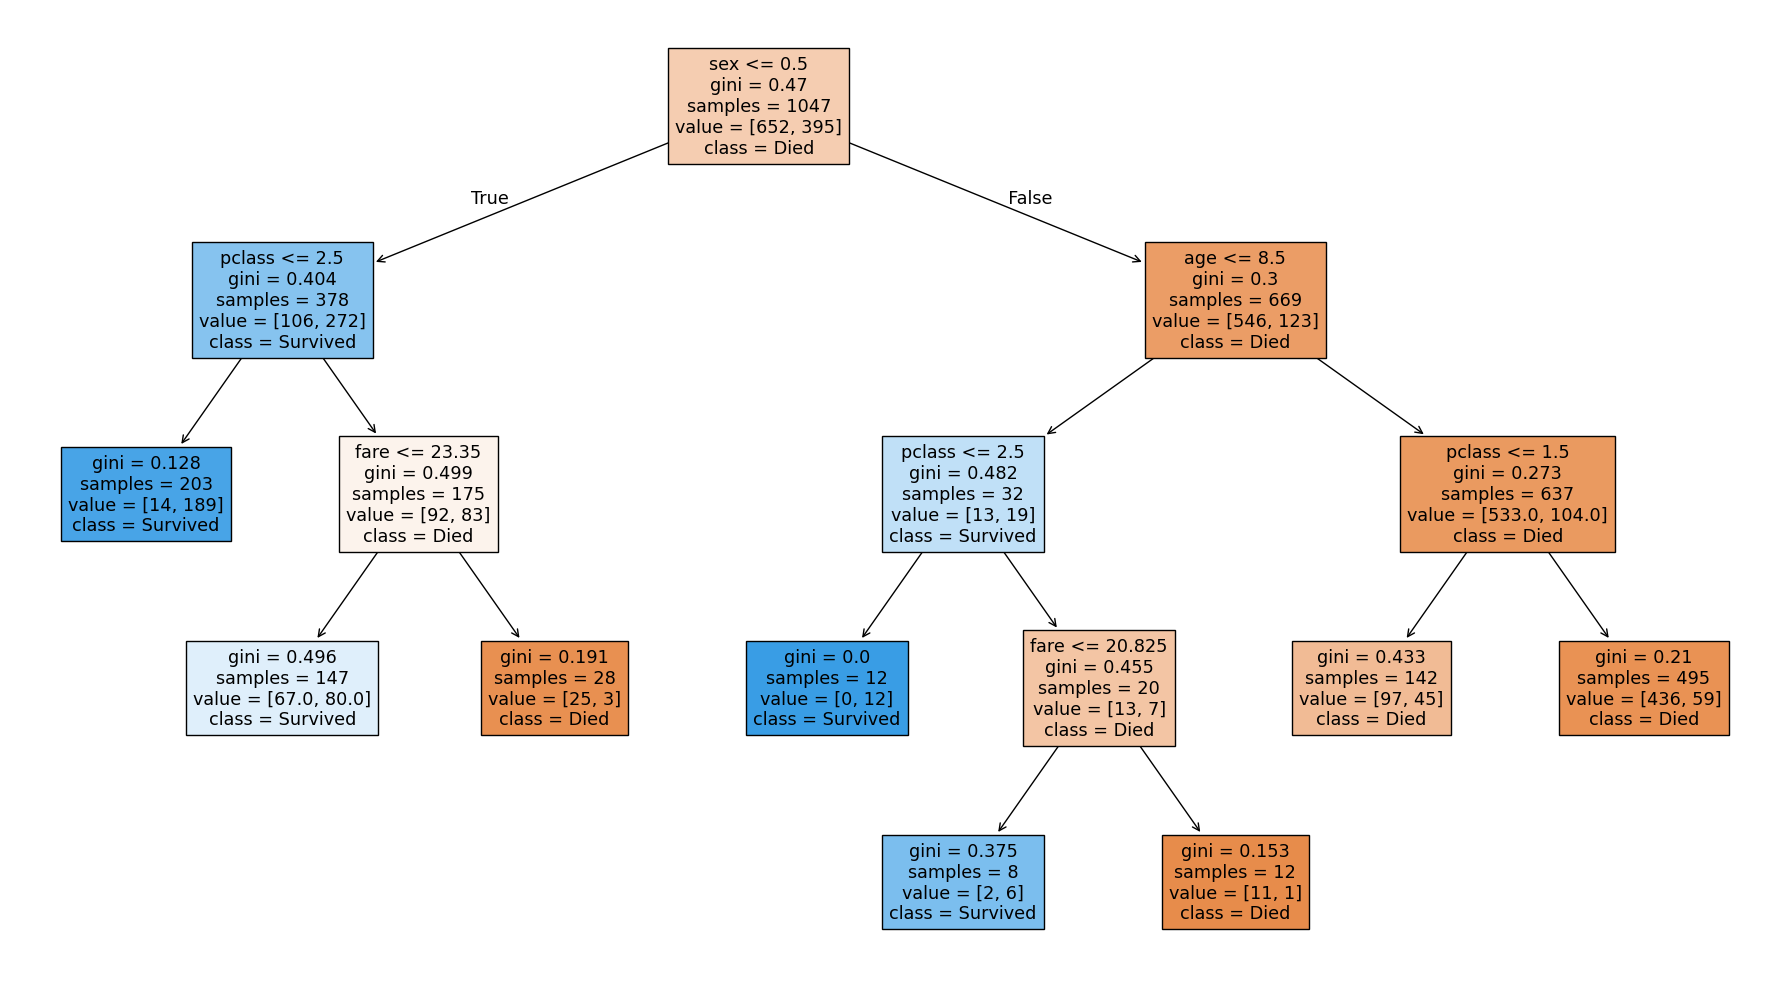

In [67]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True
)
        
plt.tight_layout()
plt.show()